# Exploratory Data Analysis (EDA)

Before any modeling, this notebook looks at how the target variable (vessel value) and the two explanatory variables (VIX and WTI) have behaved over time, and how they relate to each other. The goal is to spot patterns worth testing more rigorously in the lead-lag and regression steps that follow.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import PRIVATE_DATA

In [22]:
analysis = pd.read_csv(
    PRIVATE_DATA / "analysis_dataset.csv",
    parse_dates=["date"]
)

analysis.head()

,date,vix_level,wti_price,vix_return,wti_return,ship_value,ship_return
0,2010-03-31,17.590000,83.760002,-0.097949,0.051469,37.50,0.034483
1,2010-04-30,22.049999,86.150002,0.253553,0.028534,39.50,0.053333
2,2010-05-31,32.070000,73.970001,0.454422,-0.141381,41.00,0.037975
3,2010-06-30,34.540001,75.629997,0.077019,0.022441,40.25,-0.018293
4,2010-07-31,23.500000,78.949997,-0.319629,0.043898,38.00,-0.055901


In [23]:
analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         193 non-null    datetime64[us]
 1   vix_level    193 non-null    float64       
 2   wti_price    193 non-null    float64       
 3   vix_return   193 non-null    float64       
 4   wti_return   193 non-null    float64       
 5   ship_value   193 non-null    float64       
 6   ship_return  193 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 10.7 KB


## Ship Value Over Time

Starting with the target variable itself, since its long-term dynamics need to be understood before bringing in anything else.

In [24]:
analysis["ship_value_12m_ma"] = (
    analysis["ship_value"]
    .rolling(window=12)
    .mean()
)

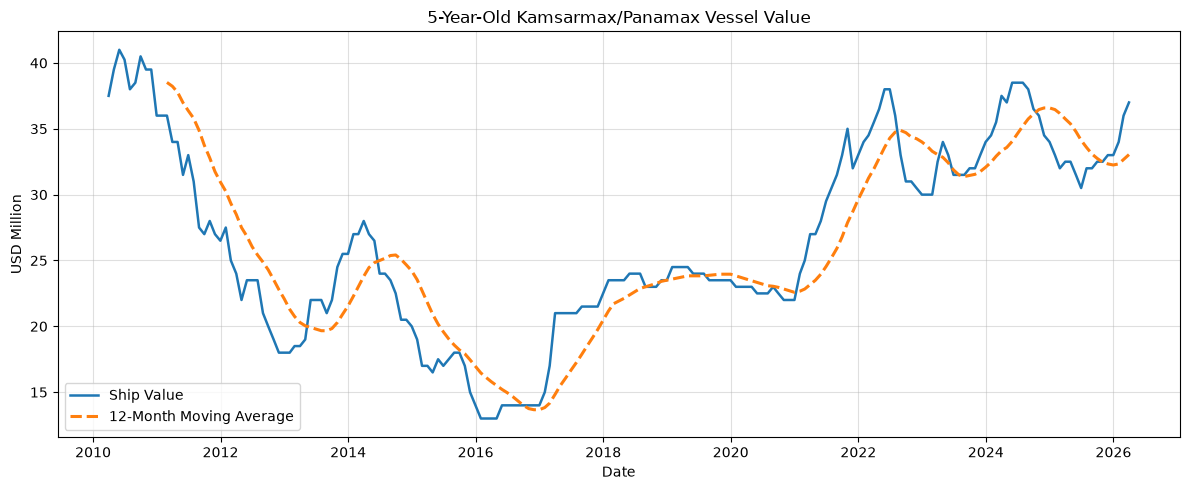

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    analysis["date"],
    analysis["ship_value"],
    label="Ship Value",
    linewidth=1.8
)

plt.plot(
    analysis["date"],
    analysis["ship_value_12m_ma"],
    label="12-Month Moving Average",
    linewidth=2.2,
    linestyle="--"
)

plt.title("5-Year-Old Kamsarmax/Panamax Vessel Value")
plt.xlabel("Date")
plt.ylabel("USD Million")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Vessel values show pronounced cyclical behavior — prices fell substantially between 2010 and 2016, then recovered after 2021. The 12-month moving average confirms these are sustained cycles, not short-term noise. For ship-finance lenders, swings of this size translate directly into collateral risk, which is exactly why finding an earlier warning signal matters.

## VIX Over Time

VIX is one of the two explanatory variables in this study, representing market-wide uncertainty.

In [26]:
analysis["vix_12m_ma"] = (
    analysis["vix_level"]
    .rolling(window=12)
    .mean()
)

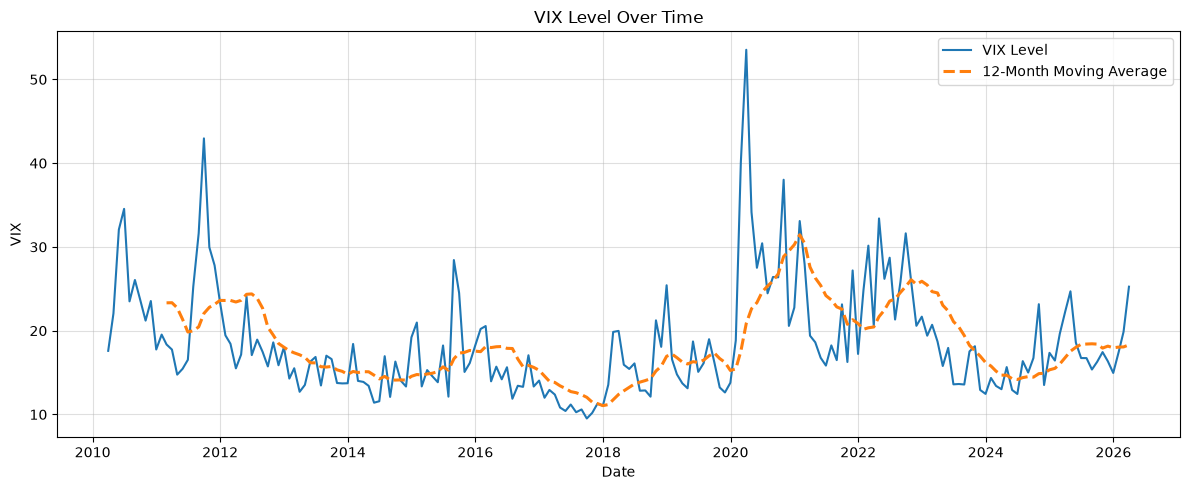

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    analysis["date"],
    analysis["vix_level"],
    label="VIX Level",
    linewidth=1.5
)

plt.plot(
    analysis["date"],
    analysis["vix_12m_ma"],
    label="12-Month Moving Average",
    linewidth=2.2,
    linestyle="--"
)

plt.title("VIX Level Over Time")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

It stays fairly stable most of the time, punctuated by sharp, short-lived spikes during stress events — 2020 being the clearest example. The moving average shows these spikes are temporary rather than a shift into a sustained high-volatility regime, which suggests any effect on asset markets is more likely to show up with a delay than immediately.

## WTI Price Over Time

The second explanatory variable, WTI reflects broader economic conditions and, indirectly, shipping operating costs.

In [28]:
analysis["wti_12m_ma"] = (
    analysis["wti_price"]
    .rolling(window=12)
    .mean()
)

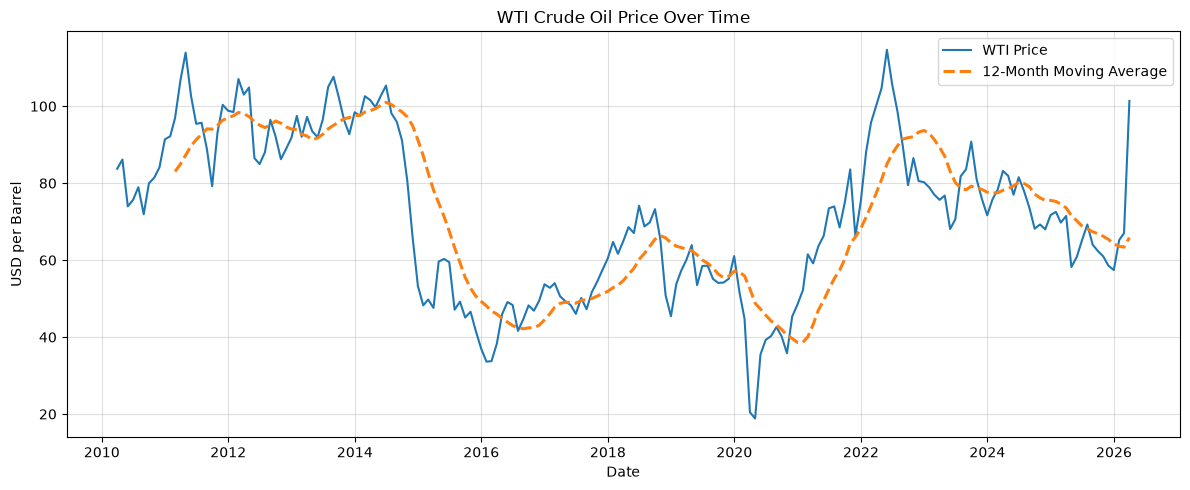

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(
    analysis["date"],
    analysis["wti_price"],
    label="WTI Price",
    linewidth=1.5
)

plt.plot(
    analysis["date"],
    analysis["wti_12m_ma"],
    label="12-Month Moving Average",
    linewidth=2.2,
    linestyle="--"
)

plt.title("WTI Crude Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("USD per Barrel")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

WTI shows clear cyclical movement, with major structural breaks around 2014–2016, 2020, and 2022. The moving average highlights how prolonged these commodity cycles tend to be — oil prices are picking up shifts in the global macro environment that plausibly feed through into shipping activity and vessel values over time.

## Distribution of Monthly Ship Return

Since the regression models work with monthly returns rather than price levels, it's worth understanding what that return distribution actually looks like first.

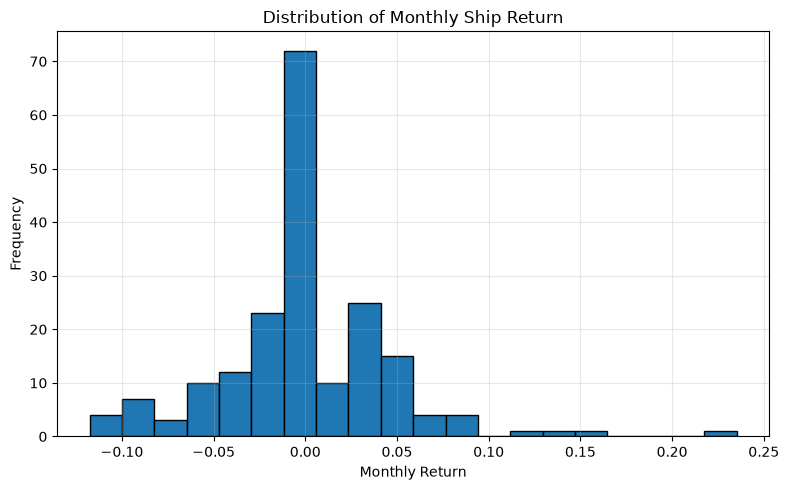

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(
    analysis["ship_return"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Monthly Ship Return")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
ship_return_summary = analysis["ship_return"].describe()

ship_return_skewness = analysis["ship_return"].skew()
ship_return_kurtosis = analysis["ship_return"].kurtosis()

print(ship_return_summary)
print()
print(f"Skewness: {ship_return_skewness:.3f}")
print(f"Kurtosis: {ship_return_kurtosis:.3f}")

count    193.000000
mean       0.001124
std        0.045584
min       -0.117647
25%       -0.020408
50%        0.000000
75%        0.027778
max        0.235294
Name: ship_return, dtype: float64

Skewness: 0.663
Kurtosis: 4.092


Most monthly returns cluster around zero, with a distribution that's positively skewed and has fairly heavy tails — occasional large moves rather than a smooth bell curve. The standard deviation comes out to about 4.6%, though individual months can swing well beyond that. In practice, vessel prices are calm in a typical month but capable of sharp, infrequent shocks — a fairly standard feature of cyclical shipping markets.

## Correlation Matrix

Before jumping into lead-lag analysis, a simple correlation matrix gives a first look at how these variables move together at the same point in time.

In [32]:
correlation_columns = [
    "ship_value",
    "ship_return",
    "vix_level",
    "vix_return",
    "wti_price",
    "wti_return",
]

correlation_matrix = analysis[correlation_columns].corr()

correlation_matrix

,ship_value,ship_return,vix_level,vix_return,wti_price,wti_return
ship_value,1.000000,0.073577,0.225117,0.013354,0.464358,0.043098
ship_return,0.073577,1.000000,-0.075139,-0.005906,-0.060307,0.083495
vix_level,0.225117,-0.075139,1.000000,0.429528,-0.072852,-0.139276
vix_return,0.013354,-0.005906,0.429528,1.000000,-0.046510,-0.234422
wti_price,0.464358,-0.060307,-0.072852,-0.046510,1.000000,0.105008
wti_return,0.043098,0.083495,-0.139276,-0.234422,0.105008,1.000000


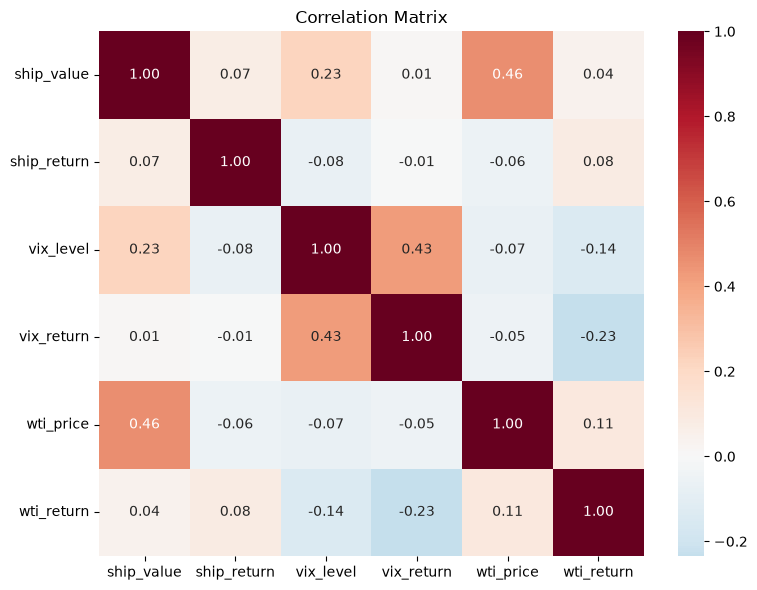

In [33]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Ship value has a moderate positive correlation with WTI price (~0.46), but that relationship largely disappears once you switch to returns — ship return and WTI return correlate at only about 0.08. That gap between level and return correlations matters: it suggests the two series may just be riding similar long-term trends rather than moving together in any short-term, predictive way. It also means the weak same-month relationship doesn't rule out a lagged one — which is the next thing worth checking.

## Ship Return vs. VIX Return

A scatter plot to check visually whether VIX changes and vessel returns move together within the same month.

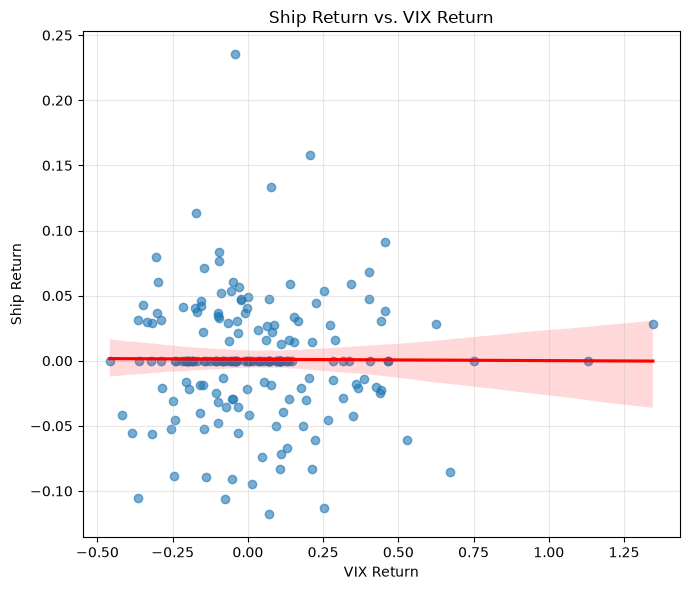

In [34]:
plt.figure(figsize=(7, 6))

sns.regplot(
    data=analysis,
    x="vix_return",
    y="ship_return",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Ship Return vs. VIX Return")
plt.xlabel("VIX Return")
plt.ylabel("Ship Return")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

They don't, really — the points are scattered widely and the fitted line is close to flat. Even sharp VIX moves don't line up consistently with sharp vessel-return moves in the same month. That's not necessarily the end of the story though; it just means if VIX has any predictive value, it's more likely to show up with a lag rather than instantaneously — which is what the next section tests directly.

# EDA Summary

A few things stood out from this pass:

- Vessel values move in long, sustained cycles rather than short-term noise.
- VIX is mostly quiet, with sharp but short-lived spikes during stress periods.
- WTI follows longer, structural commodity cycles.
- Monthly vessel returns are usually small but occasionally extreme.
- Ship value and WTI price track each other at the level, but that relationship weakens a lot once you look at returns.
- VIX shows almost no same-month relationship with vessel returns.

None of these same-month relationships are strong on their own, which is exactly why the next step — lead-lag analysis — matters: it tests whether VIX and WTI lead vessel values rather than moving with them.